In [ ]:
import pandas as pd

file_id = '1WB6LaHyhxmuyVLTbtcO5RVHY2qodCSQN'

!gdown {file_id} -O internet_service_churn.csv

# Load the CSV into a DataFrame
df = pd.read_csv('internet_service_churn.csv')
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1WB6LaHyhxmuyVLTbtcO5RVHY2qodCSQN
To: /content/internet_service_churn.csv
100% 2.68M/2.68M [00:00<00:00, 20.9MB/s]
   id  is_tv_subscriber  is_movie_package_subscriber  subscription_age  \
0  15                 1                            0             11.95   
1  18                 0                            0              8.22   
2  23                 1                            0              8.91   
3  27                 0                            0              6.87   
4  34                 0                            0              6.39   

   bill_avg  reamining_contract  service_failure_count  download_avg  \
0        25                0.14                      0           8.4   
1         0                 NaN                      0           0.0   
2        16                0.00                      0          13.7   
3        21                 NaN                      1           0.0   
4         0                 

In [ ]:
import numpy as np
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sn
import matplotlib.pyplot as plt

In [ ]:
df.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [ ]:
df.isna().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,21572
service_failure_count,0
download_avg,381
upload_avg,381
download_over_limit,0


In [ ]:
test_cols = df.columns.tolist()
test_cols.insert(5, 'is_contract')

df['is_contract'] = df['reamining_contract'].apply(lambda x: 0 if pd.isna(x) else 1)
df['reamining_contract'].replace(np.nan, 0, inplace=True)
test_prepared = df[test_cols]
column_names = ['id','is_tv_subscriber','is_movie_package_subscriber','subscription_age','bill_avg','reamining_contract',
                'is_contract','service_failure_count','download_avg','upload_avg','download_over_limit','churn']

df = df.reindex(columns=column_names)

<ipython-input-6-bf93c18b9419>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reamining_contract'].replace(np.nan, 0, inplace=True)


In [ ]:
df.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,is_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,1,0,8.4,2.3,0,0
1,18,0,0,8.22,0,0.00,0,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,1,0,13.7,0.9,0,1
3,27,0,0,6.87,21,0.00,0,1,0.0,0.0,0,1
4,34,0,0,6.39,0,0.00,0,0,0.0,0.0,0,1


In [ ]:
df['download_avg'].replace('', np.nan, inplace=True)
df['upload_avg'].replace('',np.nan, inplace=True)
df.dropna(subset=['download_avg'], inplace=True)
df.dropna(subset=['upload_avg'], inplace=True)

<ipython-input-8-df1da8737c5e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['download_avg'].replace('', np.nan, inplace=True)
<ipython-input-8-df1da8737c5e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df.isna().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,0
is_contract,0
service_failure_count,0
download_avg,0
upload_avg,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71893 entries, 0 to 72273
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           71893 non-null  int64  
 1   is_tv_subscriber             71893 non-null  int64  
 2   is_movie_package_subscriber  71893 non-null  int64  
 3   subscription_age             71893 non-null  float64
 4   bill_avg                     71893 non-null  int64  
 5   reamining_contract           71893 non-null  float64
 6   is_contract                  71893 non-null  int64  
 7   service_failure_count        71893 non-null  int64  
 8   download_avg                 71893 non-null  float64
 9   upload_avg                   71893 non-null  float64
 10  download_over_limit          71893 non-null  int64  
 11  churn                        71893 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 7.1 MB


In [ ]:
# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_data.csv', index=False)
from google.colab import files
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<ipython-input-12-7bcef35d98f9>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sn.countplot(x='churn', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})


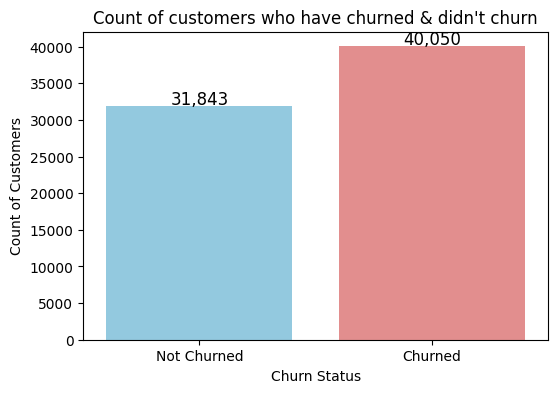

In [ ]:
# Set the figure size
plt.figure(figsize=(6, 4))

# Create the countplot
ax = sn.countplot(x='churn', data=df, palette={'0': 'skyblue', '1': 'lightcoral'})

# Set the title and labels
plt.title("Count of customers who have churned & didn't churn")
plt.xlabel('Churn Status')
plt.ylabel('Count of Customers')

# Set x-tick labels
plt.xticks(ticks=[0, 1], labels=['Not Churned', 'Churned'], rotation=0)

# Add the count labels above each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Show the plot
plt.show()

In [ ]:
# Churn rate by TV subscription
tv_churn = df.groupby('is_tv_subscriber')['churn'].mean()
print(tv_churn)

is_tv_subscriber
0    0.900783
1    0.479176
Name: churn, dtype: float64


In [ ]:
# Churn rate by TV subscription
tv_churn = df.groupby('is_movie_package_subscriber')['churn'].mean()
print(tv_churn)

is_movie_package_subscriber
0    0.665365
1    0.341217
Name: churn, dtype: float64


In [ ]:
# Average bill for churned vs. retained customers with TV subscription
tv_bill_churn = df[df['is_tv_subscriber'] == 1].groupby('churn')['bill_avg'].mean()
print(tv_bill_churn)

churn
0    18.713939
1    18.347636
Name: bill_avg, dtype: float64


In [ ]:
# Average bill for churned vs. retained customers with movie subscription
movie_bill_churn = df[df['is_movie_package_subscriber'] == 1].groupby('churn')['bill_avg'].mean()
print(movie_bill_churn)


churn
0    19.095121
1    17.707138
Name: bill_avg, dtype: float64


In [ ]:
# Average bill for churned vs. retained customers with both subscriptions
both_bill_churn = df[(df['is_tv_subscriber'] == 1) & (df['is_movie_package_subscriber'] == 1)].groupby('churn')['bill_avg'].mean()
print(both_bill_churn)


churn
0    19.095121
1    17.708043
Name: bill_avg, dtype: float64


In [ ]:
# Average bill for churned vs. retained customers with no subscriptions
no_subs_bill_churn = df[(df['is_tv_subscriber'] == 0) & (df['is_movie_package_subscriber'] == 0)].groupby('churn')['bill_avg'].mean()
print(no_subs_bill_churn)

NameError: name 'df' is not defined

In [ ]:
service_failures = df.groupby('churn')['service_failure_count'].mean()
print(service_failures)

churn
0    0.257608
1    0.290037
Name: service_failure_count, dtype: float64


In [ ]:
# Subscription age by churn status
sub_age_churn = df.groupby('churn')['subscription_age'].mean()
print(sub_age_churn)

churn
0    2.743422
1    2.226554
Name: subscription_age, dtype: float64


In [ ]:
# Remaining contract by churn status
remaining_contract_churn = df.groupby('churn')['reamining_contract'].mean()
print(remaining_contract_churn)


churn
0    1.006538
1    0.092976
Name: reamining_contract, dtype: float64


In [ ]:
# Group by 'is_contract' and calculate churn rate
contract_churn = df.groupby('is_contract')['churn'].mean()

# Show the churn rate for customers with and without contracts
print(contract_churn)


is_contract
0    0.916396
1    0.403593
Name: churn, dtype: float64


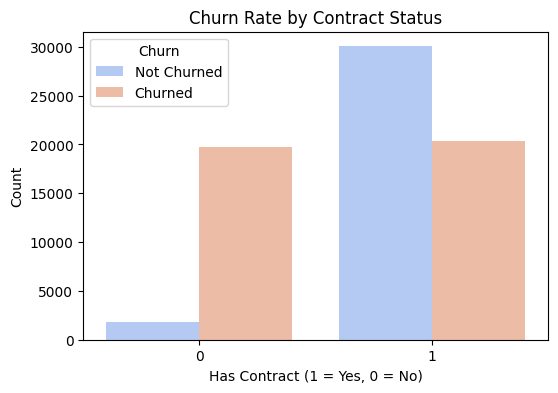

In [ ]:
# Create a bar plot for churn by contract status
plt.figure(figsize=(6, 4))
sn.countplot(x='is_contract', hue='churn', data=df, palette='coolwarm')

# Add title and labels
plt.title("Churn Rate by Contract Status")
plt.xlabel("Has Contract (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.legend(title='Churn', labels=['Not Churned', 'Churned'])
plt.show()


In [ ]:
# Calculate the percentage of churned customers for each group
churn_rate_contract = contract_churn[1] * 100  # Churn rate for customers with contract
churn_rate_no_contract = contract_churn[0] * 100  # Churn rate for customers without contract

print(f"Churn rate for customers with contract: {churn_rate_contract:.2f}%")
print(f"Churn rate for customers without contract: {churn_rate_no_contract:.2f}%")


Churn rate for customers with contract: 40.36%
Churn rate for customers without contract: 91.64%


In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['is_contract'], df['churn'])

# Perform chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Print the result
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {p_value}")

# Interpret the p-value
if p_value < 0.05:
    print("There is a significant difference in churn rates between customers with and without contracts.")
else:
    print("There is no significant difference in churn rates between customers with and without contracts.")


Chi-squared statistic: 16066.867328348286
P-value: 0.0
There is a significant difference in churn rates between customers with and without contracts.


In [ ]:
correlation = df.corr()

In [ ]:
print(correlation)

                                   id  is_tv_subscriber  \
id                           1.000000          0.283385   
is_tv_subscriber             0.283385          1.000000   
is_movie_package_subscriber  0.131648          0.337044   
subscription_age            -0.598800          0.089993   
bill_avg                     0.028724         -0.076198   
reamining_contract           0.447058          0.257424   
is_contract                  0.436729          0.310062   
service_failure_count       -0.024655         -0.016023   
download_avg                 0.241278          0.131650   
upload_avg                   0.145936          0.065791   
download_over_limit         -0.229176         -0.103807   
churn                       -0.448660         -0.329417   

                             is_movie_package_subscriber  subscription_age  \
id                                              0.131648         -0.598800   
is_tv_subscriber                                0.337044          0.089993  

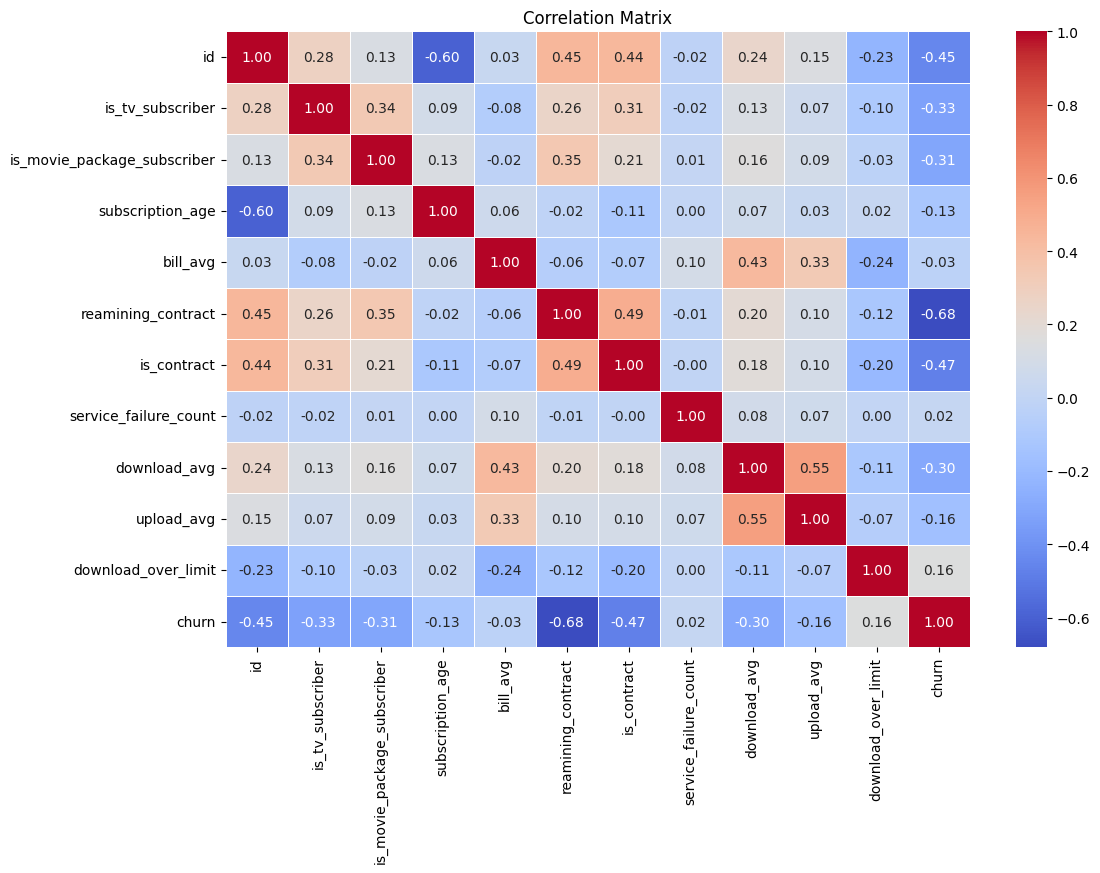

In [ ]:
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 8))
sn.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
print(correlation['churn'])  # To see the correlation between churn and other variables


id                            -0.448660
is_tv_subscriber              -0.329417
is_movie_package_subscriber   -0.307789
subscription_age              -0.126672
bill_avg                      -0.027550
reamining_contract            -0.681629
is_contract                   -0.472771
service_failure_count          0.019680
download_avg                  -0.298063
upload_avg                    -0.162690
download_over_limit            0.157626
churn                          1.000000
Name: churn, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select relevant columns for clustering
features = ['bill_avg', 'service_failure_count', 'subscription_age', 'download_avg', 'is_tv_subscriber', 'is_movie_package_subscriber', 'reamining_contract']
X = df[features]

# Normalize the data (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# You now have X_scaled, which is the normalized data for clustering


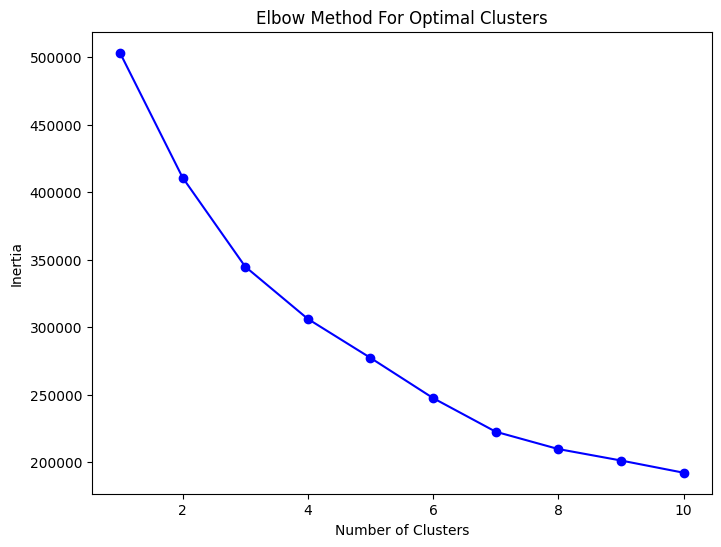

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow Method to determine optimal number of clusters
inertia = []
for i in range(1, 11):  # Check for clusters from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the inertia to visualize the "elbow"
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', color='b')
plt.title('Elbow Method For Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
from sklearn.cluster import KMeans

# Perform K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Add the cluster labels to the dataframe
df['cluster'] = kmeans.labels_

In [ ]:
# Check how many customers belong to each cluster
print(df['cluster'].value_counts())

# Show the cluster centers (average values for each cluster)
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(cluster_centers)


cluster
0    33512
1    23153
2    12740
3     2488
Name: count, dtype: int64
   bill_avg  service_failure_count  subscription_age  download_avg  \
0 -0.069333              -0.144152         -0.064501     -0.078810   
1 -0.070873              -0.124425          0.196566      0.190145   
2  0.004840              -0.109765         -0.188930     -0.371327   
3  1.575144               3.676891          0.007229      1.198750   

   is_tv_subscriber  is_movie_package_subscriber  reamining_contract  
0          0.476083                    -0.708273           -0.131573  
1          0.476083                     1.409505            0.493565  
2         -2.100476                    -0.707940           -0.539750  
3         -0.086435                     0.049782           -0.056714  


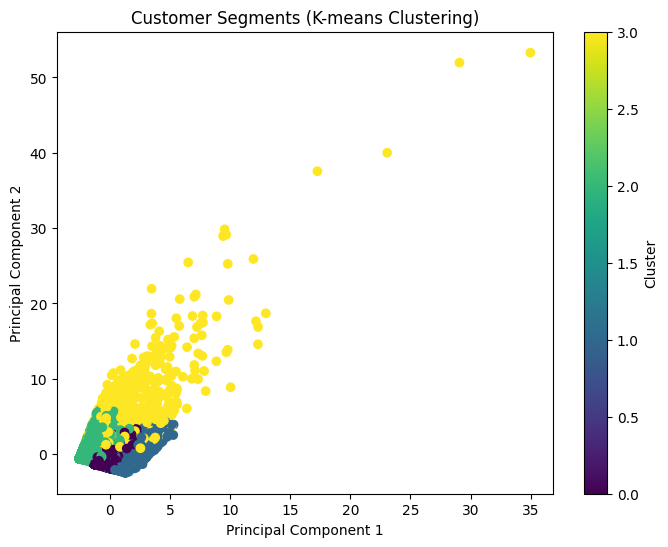

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the dimensionality to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis')
plt.title("Customer Segments (K-means Clustering)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
green_cluster = df[df['cluster'] == 3]


In [ ]:
green_cluster.describe()


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,is_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,cluster
count,2.488000e+03,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.000000,2488.0
mean,8.576208e+05,0.781350,0.356913,2.473581,39.791399,0.459622,0.682878,3.278537,119.654904,13.222548,0.143891,0.556672,3.0
std,4.803544e+05,0.413413,0.479185,2.058516,45.445818,0.647051,0.465449,2.098497,220.961007,26.772168,0.801207,0.496878,0.0
min,6.960000e+02,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0
25%,4.512432e+05,1.000000,0.000000,0.860000,18.000000,0.000000,0.000000,2.000000,19.700000,1.500000,0.000000,0.000000,3.0
50%,8.698615e+05,1.000000,0.000000,1.980000,23.000000,0.000000,1.000000,3.000000,62.250000,5.100000,0.000000,1.000000,3.0
75%,1.282709e+06,1.000000,1.000000,3.490000,39.250000,0.980000,1.000000,4.000000,137.700000,12.800000,0.000000,1.000000,3.0
max,1.688796e+06,1.000000,1.000000,11.930000,406.000000,2.590000,1.000000,19.000000,4415.200000,308.600000,7.000000,1.000000,3.0


In [ ]:
blue_cluster = df[df['cluster'] == 0]
blue_cluster.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,is_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,cluster
count,3.351200e+04,33512.0,33512.0,33512.000000,33512.000000,33512.000000,33512.000000,33512.000000,33512.000000,33512.000000,33512.000000,33512.00000,33512.0
mean,8.941894e+05,1.0,0.0,2.324492,18.101307,0.410043,0.722219,0.157406,38.690499,3.587464,0.151289,0.57454,0.0
std,4.549868e+05,0.0,0.0,1.893206,8.568156,0.594484,0.447912,0.430780,40.990023,6.766424,0.861044,0.49442,0.0
min,1.500000e+01,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
25%,5.109900e+05,1.0,0.0,0.970000,13.000000,0.000000,0.000000,0.000000,9.100000,0.700000,0.000000,0.00000,0.0
50%,9.351030e+05,1.0,0.0,1.930000,19.000000,0.000000,1.000000,0.000000,27.400000,2.000000,0.000000,1.00000,0.0
75%,1.281724e+06,1.0,0.0,3.060000,22.000000,0.860000,1.000000,0.000000,54.800000,4.400000,0.000000,1.00000,0.0
max,1.689679e+06,1.0,0.0,11.950000,98.000000,2.920000,1.000000,2.000000,532.600000,373.100000,7.000000,1.00000,0.0


In [ ]:
toska_cluster = df[df['cluster'] == 1]
toska_cluster.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,is_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,cluster
count,2.315300e+04,23153.0,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.000000,23153.0
mean,9.316401e+05,1.0,0.998877,2.853723,18.081588,0.826154,0.835615,0.173671,55.736730,5.239014,0.171641,0.339913,1.0
std,4.981790e+05,0.0,0.033493,2.276591,8.634798,0.722683,0.370632,0.450019,54.916092,11.020734,0.895400,0.473690,0.0
min,5.600000e+01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,5.020540e+05,1.0,1.000000,0.980000,13.000000,0.000000,1.000000,0.000000,16.300000,1.200000,0.000000,0.000000,1.0
50%,9.901990e+05,1.0,1.000000,2.240000,18.000000,0.880000,1.000000,0.000000,41.700000,3.200000,0.000000,0.000000,1.0
75%,1.382773e+06,1.0,1.000000,4.120000,22.000000,1.500000,1.000000,0.000000,78.900000,6.100000,0.000000,1.000000,1.0
max,1.689744e+06,1.0,1.000000,12.800000,103.000000,2.780000,1.000000,3.000000,626.200000,453.300000,7.000000,1.000000,1.0


In [ ]:
yellow_cluster = df[df['cluster'] == 2]
yellow_cluster.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,is_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,cluster
count,1.274000e+04,12740.0,12740.000000,12740.00000,12740.000000,12740.000000,12740.000000,12740.000000,12740.000000,12740.000000,12740.000000,12740.000000,12740.0
mean,5.460381e+05,0.0,0.000157,2.07279,19.067739,0.138306,0.402355,0.185714,20.112159,2.116264,0.439796,0.905887,2.0
std,4.351128e+05,0.0,0.012529,1.74039,12.715694,0.441599,0.490392,0.490157,35.262862,6.308268,1.428760,0.291997,0.0
min,1.800000e+01,0.0,0.000000,-0.02000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0
25%,2.025810e+05,0.0,0.000000,0.80000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.0
50%,4.590200e+05,0.0,0.000000,1.75000,21.000000,0.000000,0.000000,0.000000,4.500000,0.400000,0.000000,1.000000,2.0
75%,7.478395e+05,0.0,0.000000,2.76000,24.000000,0.000000,1.000000,0.000000,25.325000,2.000000,0.000000,1.000000,2.0
max,1.689733e+06,0.0,1.000000,12.61000,119.000000,2.170000,1.000000,3.000000,420.700000,308.600000,7.000000,1.000000,2.0


In [ ]:
# Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming you have your features and target variable ready
features = ['bill_avg', 'service_failure_count', 'subscription_age', 'download_avg',
            'is_tv_subscriber', 'is_movie_package_subscriber', 'reamining_contract']
X = df[features]  # Features
y = df['churn']  # Target variable (churn)

# Splitting the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (you've already done this step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model: RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)  # You can adjust these parameters

# Training the model
model.fit(X_train_scaled, y_train)

# Making predictions
y_pred = model.predict(X_test_scaled)

# Evaluating the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC Score
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1 (churn)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc}")


Accuracy: 0.9340712556208924
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6553
           1       0.94      0.93      0.94      7902

    accuracy                           0.93     14455
   macro avg       0.93      0.93      0.93     14455
weighted avg       0.93      0.93      0.93     14455

ROC-AUC Score: 0.9615953526225022


In [ ]:
# Calculate accuracy on the training set
y_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate accuracy on the testing set
y_test_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")


Training Accuracy: 0.9343295456510835
Testing Accuracy: 0.9340712556208924


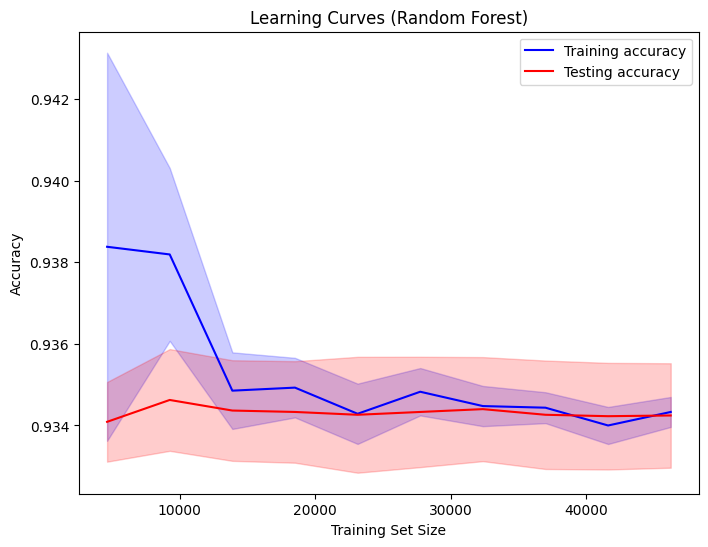

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

# Calculate the mean and standard deviation for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot the learning curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training accuracy', color='blue')
plt.plot(train_sizes, test_mean, label='Testing accuracy', color='red')
plt.fill_between(train_sizes, train_mean - train_scores.std(axis=1), train_mean + train_scores.std(axis=1), color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_scores.std(axis=1), test_mean + test_scores.std(axis=1), color='red', alpha=0.2)
plt.title("Learning Curves (Random Forest)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
!pip install shap

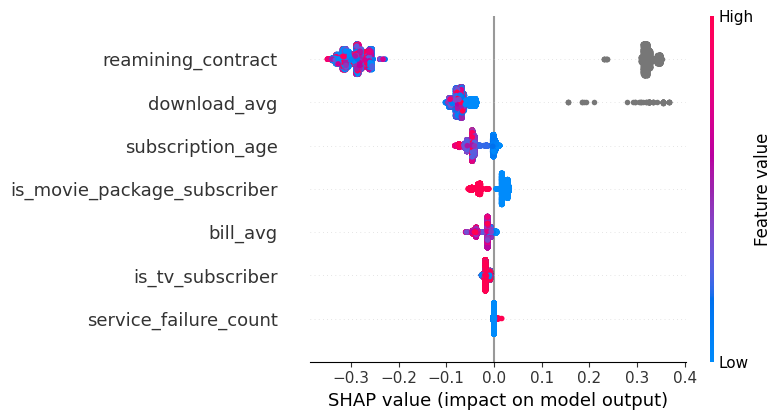

In [ ]:
import shap

# Initialize the SHAP Explainer for RandomForestClassifier
# Create a Tree SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:,:,1], X_test)


In [ ]:
# Evaluate on training data
y_train_pred = model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Evaluate on test data
y_test_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print out the results
print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

# Compare accuracies
if train_accuracy > test_accuracy:
    print("The model might be overfitting.")
elif train_accuracy < test_accuracy:
    print("The model might be underfitting.")
else:
    print("The model is well-fit.")


Training Accuracy: 0.9427869731403172
Test Accuracy: 0.9403666551366309
The model might be overfitting.
